In [10]:
from google.colab import files
import pandas as pd

# Upload the two CSV files
uploaded = files.upload()

# Display the uploaded filenames
uploaded_names = list(uploaded.keys())
print("Uploaded files:", uploaded_names)

# Automatically identify each file
planned_file = next(
    name for name in uploaded_names
    if "eventlog ifc schependomlaan" in name.lower()
    or "planned_events" in name.lower()
)

asbuilt_file = next(
    name for name in uploaded_names
    if (
        "incl as built data.csv" in name.lower()
        or "asbuilt_events" in name.lower()
    )
    and "actors" not in name.lower()
)

# Load the files
planned = pd.read_csv(planned_file)
asbuilt = pd.read_csv(asbuilt_file)

print("Planned file:", planned_file)
print("As-built file:", asbuilt_file)
print("Planned dimensions:", planned.shape)
print("As-built dimensions:", asbuilt.shape)

display(planned.head())
display(asbuilt.head())

Saving asbuilt_events.csv.csv to asbuilt_events.csv (2).csv
Saving planned_events.csv.csv to planned_events.csv (2).csv
Uploaded files: ['asbuilt_events.csv (2).csv', 'planned_events.csv (2).csv']
Planned file: planned_events.csv (2).csv
As-built file: asbuilt_events.csv (2).csv
Planned dimensions: (7166, 10)
As-built dimensions: (7166, 11)


,BuildingGUID,GUID,ifcClass,Nl-sfb,Material,Task,Resource,TaskName,TaskStart,TaskFinish
0,2CKEPCy9T9zQMKorZoDrni,3iHy1LOhfAtfLt80$LZBqn,Slab,1320_vloeren op grondslag - constructief,IFC_betonvloer_ihw_300mm,ST00060,liftputvloer_(#5715),Stellen bruggetjes,26-2-2015,27-2-2015
1,2CKEPCy9T9zQMKorZoDrni,3iHy1LOhfAtfLt80$LZBqn,Slab,1320_vloeren op grondslag - constructief,IFC_betonvloer_ihw_300mm,ST00070,liftputvloer_(#5715),Nuts invoeren,2-3-2015,4-3-2015
2,2CKEPCy9T9zQMKorZoDrni,3iHy1LOhfAtfLt80$LZBqn,Slab,1320_vloeren op grondslag - constructief,IFC_betonvloer_ihw_300mm,ST00080,liftputvloer_(#5715),Werkvloer liftput,3-3-2015,3-3-2015
3,2CKEPCy9T9zQMKorZoDrni,3iHy1LOhfAtfLt80$LZBqn,Slab,1320_vloeren op grondslag - constructief,IFC_betonvloer_ihw_300mm,ST00100,liftputvloer_(#5715),Bekisten liftvloer,4-3-2015,4-3-2015
4,2CKEPCy9T9zQMKorZoDrni,3iHy1LOhfAtfLt80$LZBqn,Slab,1320_vloeren op grondslag - constructief,IFC_betonvloer_ihw_300mm,ST00090,liftputvloer_(#5715),Wapening liftvloer,4-3-2015,4-3-2015


,BuildingGUID,GUID,IfcClass,Nl-sfb,Material,TaskID,Resource,TaskName,TaskStart,TaskFinish,Element on time or not
0,2CKEPCy9T9zQMKorZoDrni,3iHy1LOhfAtfLt80$LZBqn,IfcSlab,1320_vloeren op grondslag - constructief,IFC_betonvloer_ihw_300mm,ST00060,liftputvloer_(#5715),Stellen bruggetjes,26-2-2015,27-2-2015,On time
1,2CKEPCy9T9zQMKorZoDrni,3iHy1LOhfAtfLt80$LZBqn,IfcSlab,1320_vloeren op grondslag - constructief,IFC_betonvloer_ihw_300mm,ST00070,liftputvloer_(#5715),Nuts invoeren,2-3-2015,4-3-2015,On time
2,2CKEPCy9T9zQMKorZoDrni,3iHy1LOhfAtfLt80$LZBqn,IfcSlab,1320_vloeren op grondslag - constructief,IFC_betonvloer_ihw_300mm,ST00080,liftputvloer_(#5715),Werkvloer liftput,3-3-2015,3-3-2015,On time
3,2CKEPCy9T9zQMKorZoDrni,3iHy1LOhfAtfLt80$LZBqn,IfcSlab,1320_vloeren op grondslag - constructief,IFC_betonvloer_ihw_300mm,ST00100,liftputvloer_(#5715),Bekisten liftvloer,4-3-2015,4-3-2015,On time
4,2CKEPCy9T9zQMKorZoDrni,3iHy1LOhfAtfLt80$LZBqn,IfcSlab,1320_vloeren op grondslag - constructief,IFC_betonvloer_ihw_300mm,ST00090,liftputvloer_(#5715),Wapening liftvloer,4-3-2015,4-3-2015,On time


In [11]:
# Make a safe working copy
planned_clean = planned.copy()
asbuilt_clean = asbuilt.copy()

# Remove accidental spaces from column names
planned_clean.columns = planned_clean.columns.str.strip()
asbuilt_clean.columns = asbuilt_clean.columns.str.strip()

# Standardize inconsistent column names
planned_clean = planned_clean.rename(columns={
    "ifcClass": "IfcClass",
    "Task": "TaskID"
})

# Standardize IFC class values
for df in [planned_clean, asbuilt_clean]:
    df["IfcClass_Clean"] = (
        df["IfcClass"]
        .astype("string")
        .str.strip()
        .str.replace(r"^Ifc", "", regex=True)
        .str.replace(" ", "", regex=False)
        .str.lower()
    )

# Convert dates
for df in [planned_clean, asbuilt_clean]:
    df["TaskStart"] = pd.to_datetime(
        df["TaskStart"],
        format="%d-%m-%Y",
        errors="coerce"
    )

    df["TaskFinish"] = pd.to_datetime(
        df["TaskFinish"],
        format="%d-%m-%Y",
        errors="coerce"
    )

    df["PlannedDurationDays"] = (
        df["TaskFinish"] - df["TaskStart"]
    ).dt.days + 1

# Standardize progress status
status_column = "Element on time or not"

asbuilt_clean[status_column] = (
    asbuilt_clean[status_column]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
)

# Generate audit summary
status_counts = (
    asbuilt_clean[status_column]
    .fillna("Missing")
    .value_counts()
)

audit_summary = pd.DataFrame({
    "Metric": [
        "Planned records",
        "As-built records",
        "Unique planned GUIDs",
        "Unique as-built GUIDs",
        "Unique activities",
        "Duplicate planned GUID-task pairs",
        "Duplicate as-built GUID-task pairs",
        "Invalid planned start dates",
        "Invalid as-built start dates",
        "On-time records",
        "Late records",
        "Missing status records"
    ],
    "Value": [
        len(planned_clean),
        len(asbuilt_clean),
        planned_clean["GUID"].nunique(dropna=True),
        asbuilt_clean["GUID"].nunique(dropna=True),
        planned_clean["TaskID"].nunique(dropna=True),
        planned_clean.duplicated(["GUID", "TaskID"]).sum(),
        asbuilt_clean.duplicated(["GUID", "TaskID"]).sum(),
        planned_clean["TaskStart"].isna().sum(),
        asbuilt_clean["TaskStart"].isna().sum(),
        status_counts.get("On time", 0),
        status_counts.get("Too late", 0),
        status_counts.get("Missing", 0)
    ]
})

display(audit_summary)

,Metric,Value
0,Planned records,7166
1,As-built records,7166
2,Unique planned GUIDs,3505
3,Unique as-built GUIDs,2358
4,Unique activities,73
5,Duplicate planned GUID-task pairs,0
6,Duplicate as-built GUID-task pairs,3504
7,Invalid planned start dates,0
8,Invalid as-built start dates,3505
9,On-time records,3467


In [12]:
late_records = asbuilt_clean[
    asbuilt_clean["Element on time or not"] == "Too late"
]

late_by_class = (
    late_records["IfcClass_Clean"]
    .value_counts()
    .rename_axis("IFC Class")
    .reset_index(name="Late Records")
)

display(late_by_class)
display(late_records.head(10))

,IFC Class,Late Records
0,window,98
1,wall,54
2,covering,28
3,door,9
4,slab,4
5,wallstandardcase,1


,BuildingGUID,GUID,IfcClass,Nl-sfb,Material,TaskID,Resource,TaskName,TaskStart,TaskFinish,Element on time or not,IfcClass_Clean,PlannedDurationDays
995,2CKEPCy9T9zQMKorZoDrni,1BnpukGqn2OfhJzX1u$fmY,IfcDoor,3130_buitenwandopeningen - gevuld met deuren,205 ongewapend beton,ST00970,merk A2_(#128666),Plaatsen kozijnen,2015-06-18,2015-06-24,Too late,door,7.0
1016,2CKEPCy9T9zQMKorZoDrni,0lVn$Y_759cQUasvxkXfoO,IfcDoor,3130_buitenwandopeningen - gevuld met deuren,205 ongewapend beton,ST00970,merk F-R_(#187290),Plaatsen kozijnen,2015-06-18,2015-06-24,Too late,door,7.0
1017,2CKEPCy9T9zQMKorZoDrni,09YgJlwtPBZPXVROIrWdz0,IfcDoor,3130_buitenwandopeningen - gevuld met deuren,205 ongewapend beton,ST00970,merk F-R_(#189383),Plaatsen kozijnen,2015-06-18,2015-06-24,Too late,door,7.0
1018,2CKEPCy9T9zQMKorZoDrni,0gW6p_9cbDu8bX7gLw9$EM,IfcDoor,3130_buitenwandopeningen - gevuld met deuren,205 ongewapend beton,ST00970,merk F-R_(#77756),Plaatsen kozijnen,2015-06-18,2015-06-24,Too late,door,7.0
1019,2CKEPCy9T9zQMKorZoDrni,2AteZfCsnB0vn3iJO7wGs6,IfcDoor,3130_buitenwandopeningen - gevuld met deuren,205 ongewapend beton,ST00970,merk F-R_(#81462),Plaatsen kozijnen,2015-06-18,2015-06-24,Too late,door,7.0
1023,2CKEPCy9T9zQMKorZoDrni,3DQAcKPffEhwOXIjeyMpIE,IfcWindow,3120_buitenwandopeningen - gevuld met ramen,205 ongewapend beton,ST00970,merk N_(#131772),Plaatsen kozijnen,2015-06-18,2015-06-24,Too late,window,7.0
1024,2CKEPCy9T9zQMKorZoDrni,0spKItsIH2hgsjBL98YGqU,IfcWindow,3120_buitenwandopeningen - gevuld met ramen,205 ongewapend beton,ST00970,merk N_(#132846),Plaatsen kozijnen,2015-06-18,2015-06-24,Too late,window,7.0
1171,2CKEPCy9T9zQMKorZoDrni,3zaIWtl1164ODDOMKPXAPD,IfcSlab,4720_dakafwerkingen - bekledingen,IFC_isolatie_110mm_glaswol,ST00510,dakisolatie_(#797154),Lijmwerk kalkzandsteen elementen,2015-06-19,2015-06-23,Too late,slab,5.0
1172,2CKEPCy9T9zQMKorZoDrni,1mxtkANs9AIxzJfMD63Vpg,IfcSlab,4720_dakafwerkingen - bekledingen,IFC_isolatie_110mm_glaswol,ST00510,dakisolatie_(#797314),Lijmwerk kalkzandsteen elementen,2015-06-19,2015-06-23,Too late,slab,5.0
1505,2CKEPCy9T9zQMKorZoDrni,28y23oYnn9ffNHFtIgG4eV,IfcWindow,3120_buitenwandopeningen - gevuld met ramen,205 ongewapend beton,ST00950,merk B1_(#389232),Stelwerk buitengevel,2015-07-02,2015-07-08,Too late,window,7.0


In [14]:
# Keep only records with a known progress status
labeled = asbuilt_clean[
    asbuilt_clean["Element on time or not"].isin(
        ["On time", "Too late"]
    )
].copy()

# Create numerical delay indicator
labeled["LateFlag"] = (
    labeled["Element on time or not"] == "Too late"
).astype(int)

# Performance by IFC class
class_performance = (
    labeled.groupby("IfcClass_Clean")
    .agg(
        Total_Records=("LateFlag", "size"),
        Late_Records=("LateFlag", "sum"),
        Unique_Elements=("GUID", "nunique"),
        Activities=("TaskID", "nunique")
    )
    .reset_index()
)

class_performance["On_Time_Records"] = (
    class_performance["Total_Records"]
    - class_performance["Late_Records"]
)

class_performance["Late_Rate_Percent"] = (
    class_performance["Late_Records"]
    / class_performance["Total_Records"]
    * 100
).round(2)

class_performance = class_performance.sort_values(
    "Late_Rate_Percent",
    ascending=False
)

display(class_performance)

,IfcClass_Clean,Total_Records,Late_Records,Unique_Elements,Activities,On_Time_Records,Late_Rate_Percent
12,window,412,98,259,7,314,23.79
5,door,84,9,66,3,75,10.71
10,wall,789,54,469,22,735,6.84
4,covering,1015,28,735,15,987,2.76
8,slab,560,4,236,39,556,0.71
11,wallstandardcase,204,1,115,19,203,0.49
2,buildingelementproxy,14,0,14,2,14,0.00
1,buildingelementpart,297,0,265,5,297,0.00
0,beam,252,0,166,14,252,0.00
3,column,11,0,11,3,11,0.00


In [15]:
task_performance = (
    labeled.groupby(["TaskID", "TaskName"])
    .agg(
        Total_Records=("LateFlag", "size"),
        Late_Records=("LateFlag", "sum"),
        Unique_Elements=("GUID", "nunique"),
        IFC_Classes=("IfcClass_Clean", "nunique"),
        Start_Date=("TaskStart", "min"),
        Finish_Date=("TaskFinish", "max")
    )
    .reset_index()
)

task_performance["Late_Rate_Percent"] = (
    task_performance["Late_Records"]
    / task_performance["Total_Records"]
    * 100
).round(2)

late_tasks = (
    task_performance[
        task_performance["Late_Records"] > 0
    ]
    .sort_values(
        ["Late_Records", "Late_Rate_Percent"],
        ascending=False
    )
)

display(late_tasks)

,TaskID,TaskName,Total_Records,Late_Records,Unique_Elements,IFC_Classes,Start_Date,Finish_Date,Late_Rate_Percent
60,ST01060,Metselwerk,527,60,527,7,2015-07-09,2015-07-21,11.39
54,ST00950,Stelwerk buitengevel,171,50,171,2,2015-07-02,2015-07-08,29.24
56,ST00980,Plaatsen kozijnen,171,50,171,2,2015-07-06,2015-07-10,29.24
61,ST01070,Metselwerk,199,13,199,2,2015-07-22,2015-08-04,6.53
58,ST01000,Prefab betonband,84,10,84,2,2015-08-17,2015-08-18,11.90
55,ST00970,Plaatsen kozijnen,176,7,176,5,2015-06-18,2015-06-24,3.98
25,ST00510,Lijmwerk kalkzandsteen elementen,19,2,19,3,2015-06-19,2015-06-23,10.53
63,ST01130,Plaatsen scharnierkap incl. goot en platte daken,313,2,313,6,2015-08-28,2015-09-17,0.64


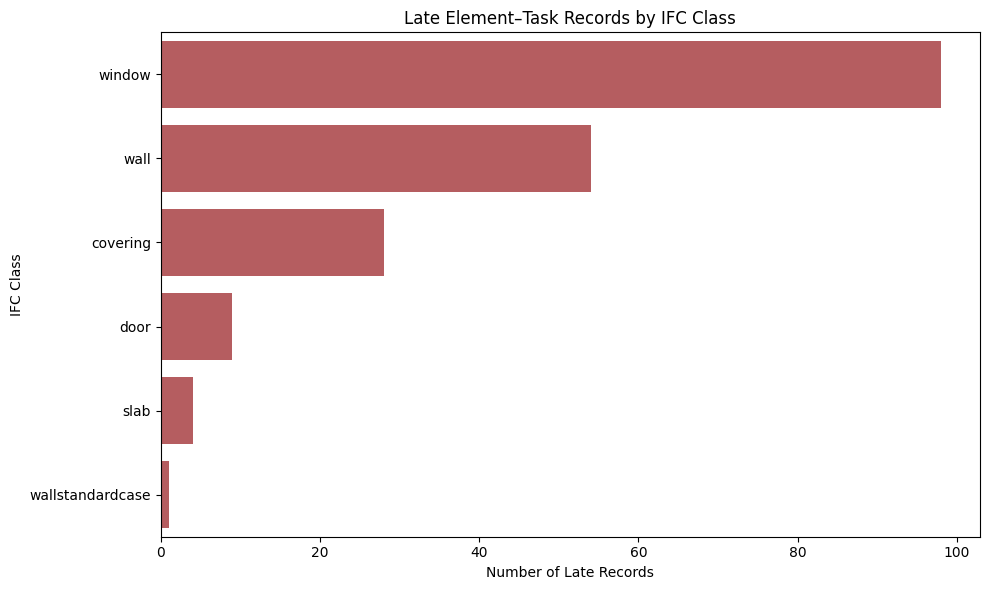

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

late_class_chart = class_performance[
    class_performance["Late_Records"] > 0
].sort_values("Late_Records", ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=late_class_chart,
    x="Late_Records",
    y="IfcClass_Clean",
    color="#C44E52"
)

plt.title("Late Element–Task Records by IFC Class")
plt.xlabel("Number of Late Records")
plt.ylabel("IFC Class")
plt.tight_layout()
plt.show()

In [18]:
display(
    late_tasks[
        [
            "TaskID",
            "TaskName",
            "Total_Records",
            "Late_Records",
            "Unique_Elements",
            "Late_Rate_Percent",
            "Start_Date",
            "Finish_Date"
        ]
    ].head(20)
)

,TaskID,TaskName,Total_Records,Late_Records,Unique_Elements,Late_Rate_Percent,Start_Date,Finish_Date
60,ST01060,Metselwerk,527,60,527,11.39,2015-07-09,2015-07-21
54,ST00950,Stelwerk buitengevel,171,50,171,29.24,2015-07-02,2015-07-08
56,ST00980,Plaatsen kozijnen,171,50,171,29.24,2015-07-06,2015-07-10
61,ST01070,Metselwerk,199,13,199,6.53,2015-07-22,2015-08-04
58,ST01000,Prefab betonband,84,10,84,11.90,2015-08-17,2015-08-18
55,ST00970,Plaatsen kozijnen,176,7,176,3.98,2015-06-18,2015-06-24
25,ST00510,Lijmwerk kalkzandsteen elementen,19,2,19,10.53,2015-06-19,2015-06-23
63,ST01130,Plaatsen scharnierkap incl. goot en platte daken,313,2,313,0.64,2015-08-28,2015-09-17


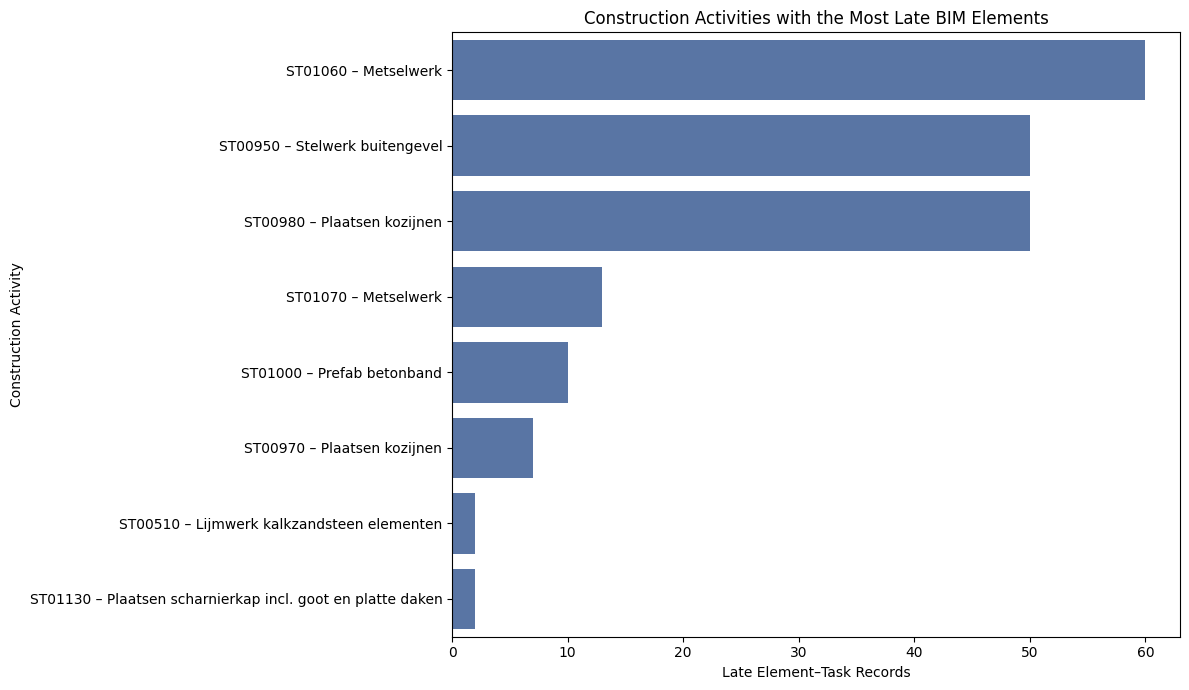

In [19]:
top_late_tasks = late_tasks.head(10).copy()

top_late_tasks["Task_Label"] = (
    top_late_tasks["TaskID"]
    + " – "
    + top_late_tasks["TaskName"]
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_late_tasks,
    x="Late_Records",
    y="Task_Label",
    color="#4C72B0"
)

plt.title("Construction Activities with the Most Late BIM Elements")
plt.xlabel("Late Element–Task Records")
plt.ylabel("Construction Activity")
plt.tight_layout()
plt.show()

In [20]:
task_details = late_tasks[
    [
        "TaskID",
        "TaskName",
        "Total_Records",
        "Late_Records",
        "Unique_Elements",
        "Late_Rate_Percent",
        "Start_Date",
        "Finish_Date"
    ]
].copy()

display(task_details)

,TaskID,TaskName,Total_Records,Late_Records,Unique_Elements,Late_Rate_Percent,Start_Date,Finish_Date
60,ST01060,Metselwerk,527,60,527,11.39,2015-07-09,2015-07-21
54,ST00950,Stelwerk buitengevel,171,50,171,29.24,2015-07-02,2015-07-08
56,ST00980,Plaatsen kozijnen,171,50,171,29.24,2015-07-06,2015-07-10
61,ST01070,Metselwerk,199,13,199,6.53,2015-07-22,2015-08-04
58,ST01000,Prefab betonband,84,10,84,11.90,2015-08-17,2015-08-18
55,ST00970,Plaatsen kozijnen,176,7,176,3.98,2015-06-18,2015-06-24
25,ST00510,Lijmwerk kalkzandsteen elementen,19,2,19,10.53,2015-06-19,2015-06-23
63,ST01130,Plaatsen scharnierkap incl. goot en platte daken,313,2,313,0.64,2015-08-28,2015-09-17


In [21]:
late_records = labeled[
    labeled["LateFlag"] == 1
].copy()

late_records["Task_Label"] = (
    late_records["TaskID"]
    + " – "
    + late_records["TaskName"]
)

task_class_matrix = pd.crosstab(
    late_records["Task_Label"],
    late_records["IfcClass_Clean"]
)

# Arrange activities by their total late records
task_order = (
    task_class_matrix.sum(axis=1)
    .sort_values(ascending=False)
    .index
)

task_class_matrix = task_class_matrix.loc[task_order]

display(task_class_matrix)

IfcClass_Clean,covering,door,slab,wall,wallstandardcase,window
Task_Label,,,,,,
ST01060 – Metselwerk,15,0,0,44,1,0
ST00950 – Stelwerk buitengevel,0,2,0,0,0,48
ST00980 – Plaatsen kozijnen,0,2,0,0,0,48
ST01070 – Metselwerk,3,0,0,10,0,0
ST01000 – Prefab betonband,10,0,0,0,0,0
ST00970 – Plaatsen kozijnen,0,5,0,0,0,2
ST00510 – Lijmwerk kalkzandsteen elementen,0,0,2,0,0,0
ST01130 – Plaatsen scharnierkap incl. goot en platte daken,0,0,2,0,0,0


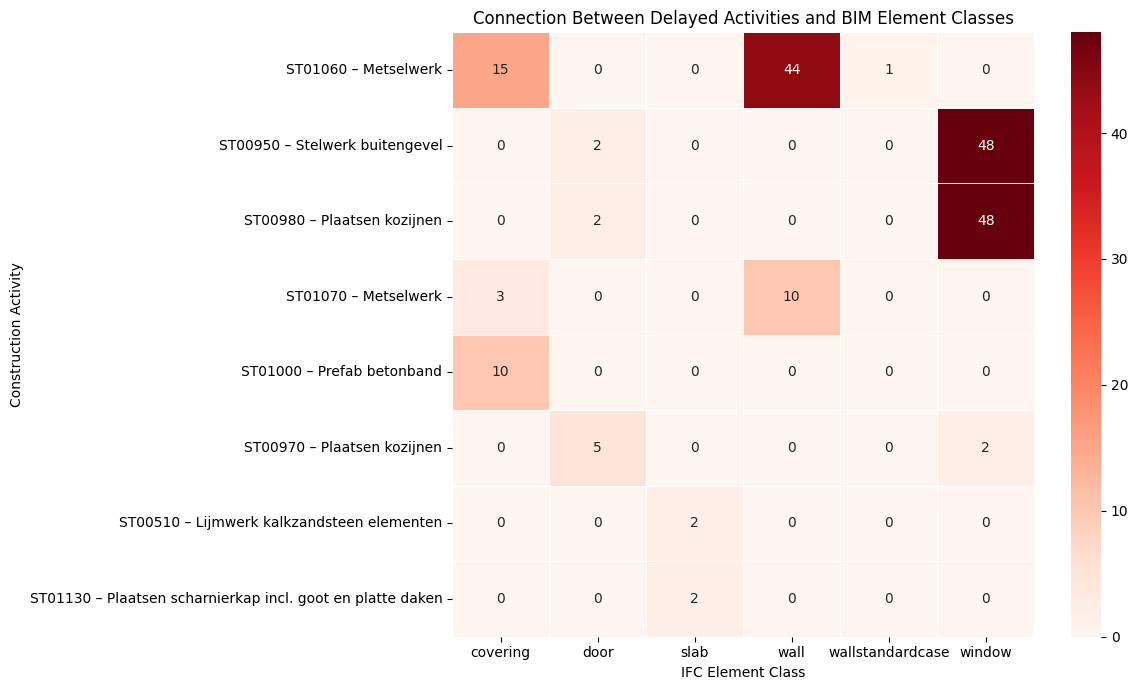

In [22]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    task_class_matrix,
    annot=True,
    fmt="g",
    cmap="Reds",
    linewidths=0.5
)

plt.title("Connection Between Delayed Activities and BIM Element Classes")
plt.xlabel("IFC Element Class")
plt.ylabel("Construction Activity")
plt.tight_layout()
plt.show()

In [23]:
status_column = "Element on time or not"

missing_status = asbuilt_clean[
    asbuilt_clean[status_column].isna()
].copy()

print("Records with missing status:", len(missing_status))

missing_profile = pd.DataFrame({
    "Column": missing_status.columns,
    "Non_Missing_Records": [
        missing_status[column].notna().sum()
        for column in missing_status.columns
    ],
    "Unique_Values": [
        missing_status[column].nunique(dropna=True)
        for column in missing_status.columns
    ]
})

display(missing_profile)
display(missing_status.head(10))

Records with missing status: 3505


,Column,Non_Missing_Records,Unique_Values
0,BuildingGUID,0,0
1,GUID,0,0
2,IfcClass,0,0
3,Nl-sfb,0,0
4,Material,0,0
5,TaskID,0,0
6,Resource,0,0
7,TaskName,0,0
8,TaskStart,0,0
9,TaskFinish,0,0


,BuildingGUID,GUID,IfcClass,Nl-sfb,Material,TaskID,Resource,TaskName,TaskStart,TaskFinish,Element on time or not,IfcClass_Clean,PlannedDurationDays
3661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,<NA>,<NA>,NaN
3662,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,<NA>,<NA>,NaN
3663,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,<NA>,<NA>,NaN
3664,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,<NA>,<NA>,NaN
3665,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,<NA>,<NA>,NaN
3666,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,<NA>,<NA>,NaN
3667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,<NA>,<NA>,NaN
3668,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,<NA>,<NA>,NaN
3669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,<NA>,<NA>,NaN
3670,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,<NA>,<NA>,NaN


In [25]:
print(
    "Missing-status records with GUID:",
    missing_status["GUID"].notna().sum()
)

print(
    "Missing-status records with TaskID:",
    missing_status["TaskID"].notna().sum()
)

print(
    "Missing-status records with TaskName:",
    missing_status["TaskName"].notna().sum()
)

Missing-status records with GUID: 0
Missing-status records with TaskID: 0
Missing-status records with TaskName: 0


In [26]:
# Retain only usable as-built element–task records
asbuilt_valid = asbuilt_clean.dropna(
    subset=[
        "GUID",
        "TaskID",
        "TaskName",
        "Element on time or not"
    ]
).copy()

# Retain valid planned records
planned_valid = planned_clean.dropna(
    subset=[
        "GUID",
        "TaskID",
        "TaskName"
    ]
).copy()

print("Valid planned records:", len(planned_valid))
print("Valid as-built records:", len(asbuilt_valid))

print(
    "\nAs-built status distribution:"
)

print(
    asbuilt_valid["Element on time or not"]
    .value_counts()
)

record_coverage = (
    len(asbuilt_valid) / len(planned_valid) * 100
)

print(
    f"\nAs-built record coverage: {record_coverage:.2f}%"
)

Valid planned records: 7166
Valid as-built records: 3661

As-built status distribution:
Element on time or not
On time     3467
Too late     194
Name: count, dtype: Int64

As-built record coverage: 51.09%


In [27]:
planned_valid.to_csv(
    "planned_events_cleaned.csv",
    index=False
)

asbuilt_valid.to_csv(
    "asbuilt_events_cleaned.csv",
    index=False
)

from google.colab import files

files.download("planned_events_cleaned.csv")
files.download("asbuilt_events_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>